# Apache Drill as a federated SQL query engine

**Dataset**: HealthData.gov (U.S. Department of Health & Human Services), COVID-19


In [2]:
import time
import statistics
import requests
import pandas as pd
import matplotlib.pyplot as plt

DRILL_REST = "http://drill:8047/query.json"
DRILL_PROFILE = "http://drill:8047/profiles/{}.json"

def drill_query(sql: str, label: str = None, group: str = None, repeats: int = 3):
    """ (GET /profiles/{queryId}.json)
        (POST /query.json)
        """


    payload = {"queryType": "SQL", "query": sql}
    wall_times = []
    data = None

    for _ in range(repeats):
        init = time.perf_counter()
        r = requests.post(DRILL_REST, json=payload, timeout=120) #POST 
        wall_times.append(time.perf_counter() - init)

        r.raise_for_status()  #raise an exception for errors
        data = r.json()

        if data.get("queryState") == "FAILED": 
            raise RuntimeError(f"ERROR: {data}")

    profile = requests.get(DRILL_PROFILE.format(data["queryId"]), timeout=30).json() #!  GET
    print(profile)


    planning_ms = profile["planEnd"] - profile["start"]
    queued_ms = profile["queueWaitEnd"] - profile["planEnd"]
    execution_ms = profile["end"] - profile["queueWaitEnd"]

    df = pd.DataFrame(data.get("rows", []), columns=data.get("columns", []))
    median_seconds = statistics.median(wall_times)

    timings.append({
        "query": label,
        "group": group,
        "seconds": median_seconds,
        "rows": len(df),
        "planning_ms": planning_ms,
        "queued_ms": queued_ms,
        "execution_ms": execution_ms,
    })

    print(f"{label} median={median_seconds:.3f}s (n={repeats}) -- {len(df)} rows "
          f"[plan {planning_ms}ms / queue {queued_ms}ms / exec {execution_ms}ms]")
    return df

timings = []  # accumulates execution times for every query run in this notebook

# sanity check
drill_query("SELECT * FROM sys.version", label="sanity-check", group="setup")

{'id': {'part1': 1543198854246339790, 'part2': 2422889873562233114}, 'type': 1, 'start': 1788179664112, 'end': 1788179664216, 'query': 'SELECT * FROM sys.version', 'plan': '00-00    Screen : rowType = RecordType(VARCHAR(65536) version, VARCHAR(65536) commit_id, VARCHAR(65536) commit_message, VARCHAR(65536) commit_time, VARCHAR(65536) build_email, VARCHAR(65536) build_time): rowcount = 20.0, cumulative cost = {42.0 rows, 242.0 cpu, 1.0 io, 0.0 network, 0.0 memory}, id = 365\n00-01      Project(version=[$0], commit_id=[$1], commit_message=[$2], commit_time=[$3], build_email=[$4], build_time=[$5]) : rowType = RecordType(VARCHAR(65536) version, VARCHAR(65536) commit_id, VARCHAR(65536) commit_message, VARCHAR(65536) commit_time, VARCHAR(65536) build_email, VARCHAR(65536) build_time): rowcount = 20.0, cumulative cost = {40.0 rows, 240.0 cpu, 1.0 io, 0.0 network, 0.0 memory}, id = 364\n00-02        Scan(table=[[sys, version]], groupscan=[SystemTableScan [table=VERSION, distributed=false]]) : 

,version,commit_id,commit_message,commit_time,build_email,build_time
0,1.21.0,ff86c29b125776c56f361fc9187fb96458de37a6,[maven-release-plugin] prepare release drill-1...,15.02.2023 @ 05:29:23 UTC,None,None


## Query 1 — Schema-on-read on raw CSV (source: `dfs`, Dataset 1)

In [3]:
q1 = """
SELECT state, `date`, covid_beds_used FROM (
  SELECT state,
         `date`,
         SUM(CAST(NULLIF(REPLACE(inpatient_beds_used_covid, ',', ''), '') AS BIGINT)) AS covid_beds_used
  FROM dfs.healthdata.`covid/hospital_capacity.csv`
  WHERE `date` >= '2021/01/01'
  GROUP BY state, `date`
) 
WHERE covid_beds_used IS NOT NULL
ORDER BY covid_beds_used DESC
LIMIT 20
"""
df1 = drill_query(q1, label="Q1 dfs-csv", group="single-source")
df1

{'id': {'part1': 1543198832876983796, 'part2': 1419944189048424290}, 'type': 1, 'start': 1788179669298, 'end': 1788179670175, 'query': "\nSELECT state, `date`, covid_beds_used FROM (\n  SELECT state,\n         `date`,\n         SUM(CAST(NULLIF(REPLACE(inpatient_beds_used_covid, ',', ''), '') AS BIGINT)) AS covid_beds_used\n  FROM dfs.healthdata.`covid/hospital_capacity.csv`\n  WHERE `date` >= '2021/01/01'\n  GROUP BY state, `date`\n) \nWHERE covid_beds_used IS NOT NULL\nORDER BY covid_beds_used DESC\nLIMIT 20\n", 'plan': '00-00    Screen : rowType = RecordType(ANY state, ANY date, BIGINT covid_beds_used): rowcount = 20.0, cumulative cost = {2074600.8639999998 rows, 1.6310183061119674E7 cpu, 5.8207647E7 io, 0.0 network, 8451743.52 memory}, id = 2072\n00-01      Project(state=[$0], date=[$1], covid_beds_used=[$2]) : rowType = RecordType(ANY state, ANY date, BIGINT covid_beds_used): rowcount = 20.0, cumulative cost = {2074598.8639999998 rows, 1.6310181061119674E7 cpu, 5.8207647E7 io, 0.0 

,state,date,covid_beds_used
0,CA,2021/01/14,30334
1,CA,2021/01/06,22872
2,CA,2021/01/07,22835
3,CA,2021/01/05,22715
4,CA,2021/01/10,22678
5,CA,2021/01/08,22636
6,CA,2021/01/11,22594
7,CA,2021/01/09,22564
8,CA,2021/01/12,22453
9,CA,2021/01/04,22445


## Query 2 — Aggregation on PostgreSQL (source: `postgreSQL`, Dataset 2)

In [4]:
q2 = """
SELECT state,
       COUNT(*) AS num_observations,
       ROUND(AVG(estimated_beds_covid), 0)  AS avg_estimated_beds_covid,
       ROUND(AVG(pct_beds_covid), 4)   AS avg_pct_covid
FROM pg.healthdata.estimated_beds
GROUP BY state
ORDER BY avg_estimated_beds_covid DESC
LIMIT 20
"""
df2 = drill_query(q2, label="Q2 postgre", group="single-source")
df2

{'id': {'part1': 1543198802639780352, 'part2': -3969976389903805999}, 'type': 1, 'start': 1788179676625, 'end': 1788179677597, 'query': '\nSELECT state,\n       COUNT(*) AS num_observations,\n       ROUND(AVG(estimated_beds_covid), 0)  AS avg_estimated_beds_covid,\n       ROUND(AVG(pct_beds_covid), 4)   AS avg_pct_covid\nFROM pg.healthdata.estimated_beds\nGROUP BY state\nORDER BY avg_estimated_beds_covid DESC\nLIMIT 20\n', 'plan': '00-00    Screen : rowType = RecordType(CHAR(2) state, BIGINT num_observations, ANY avg_estimated_beds_covid, ANY avg_pct_covid): rowcount = 20.0, cumulative cost = {3.400000142E9 rows, 6.542877169995495E10 cpu, 0.0 io, 1.392640032768E13 network, 1.76E10 memory}, id = 4031\n00-01      Project(state=[$0], num_observations=[$1], avg_estimated_beds_covid=[$2], avg_pct_covid=[$3]) : rowType = RecordType(CHAR(2) state, BIGINT num_observations, ANY avg_estimated_beds_covid, ANY avg_pct_covid): rowcount = 20.0, cumulative cost = {3.40000014E9 rows, 6.542877169795495

,state,num_observations,avg_estimated_beds_covid,avg_pct_covid
0,CW,31,24884.0,3.6145
1,FL,31,4254.0,8.2155
2,TX,31,3146.0,5.4910
3,CA,31,2137.0,3.6074
4,MO,31,1318.0,9.2265
5,GA,31,979.0,5.1148
6,NY,31,803.0,1.6984
7,NV,31,749.0,10.1061
8,OH,31,698.0,2.4335
9,AZ,31,673.0,4.8058


## Query 3 — Query on MongoDB (source: `mongo`, Dataset 3)

In [5]:
q3 = """
SELECT t.state,
       t.order_label     AS therapy_name,
       COUNT(*)          AS num_centers
FROM mongo.healthdata.therapeutic t
WHERE t.provider_status = 'ACTIVE'
GROUP BY t.state, t.order_label
ORDER BY num_centers DESC
LIMIT 20
"""
df3 = drill_query(q3, label="Q3 mongo", group="single-source")
df3

{'id': {'part1': 1543198796798943000, 'part2': -449118613374772679}, 'type': 1, 'start': 1788179678933, 'end': 1788179679072, 'query': "\nSELECT t.state,\n       t.order_label     AS therapy_name,\n       COUNT(*)          AS num_centers\nFROM mongo.healthdata.therapeutic t\nWHERE t.provider_status = 'ACTIVE'\nGROUP BY t.state, t.order_label\nORDER BY num_centers DESC\nLIMIT 20\n", 'plan': '00-00    Screen : rowType = RecordType(ANY state, ANY therapy_name, BIGINT num_centers): rowcount = 69184.0, cumulative cost = {145286.4 rows, 283654.4 cpu, 0.0 io, 0.0 network, 0.0 memory}, id = 5111\n00-01      Project(state=[$0], therapy_name=[$1], num_centers=[$2]) : rowType = RecordType(ANY state, ANY therapy_name, BIGINT num_centers): rowcount = 69184.0, cumulative cost = {138368.0 rows, 276736.0 cpu, 0.0 io, 0.0 network, 0.0 memory}, id = 5110\n00-02        Plugin(groupScan=[MongoGroupScan [MongoScanSpec=MongoScanSpec [dbName="healthdata", collectionName="therapeutic", operations=[{"$match": 

,state,therapy_name,num_centers
0,CA,Renal Paxlovid,1642
1,CA,Paxlovid,1512
2,TX,Renal Paxlovid,1072
3,CA,Lagevrio (molnupiravir),852
4,TX,Paxlovid,821
5,FL,Renal Paxlovid,777
6,PA,Renal Paxlovid,764
7,PA,Paxlovid,755
8,NY,Renal Paxlovid,740
9,NY,Paxlovid,651


## Query P — Point Lookup (source: `pg`, Dataset 2)

A single (state, date) observation

In [6]:
qp = """
SELECT * FROM pg.healthdata.estimated_beds
WHERE state = 'CA' AND collection_date = DATE '2021-07-09'
"""
dfp = drill_query(qp, label="QP point-lookup", group="single-source")
dfp

{'id': {'part1': 1543198791137850771, 'part2': 7783813263238632754}, 'type': 1, 'start': 1788179679453, 'end': 1788179679509, 'query': "\nSELECT * FROM pg.healthdata.estimated_beds\nWHERE state = 'CA' AND collection_date = DATE '2021-07-09'\n", 'plan': '00-00    Screen : rowType = RecordType(CHAR(2) state, DATE collection_date, DECIMAL(0, 0) estimated_beds_covid, DECIMAL(0, 0) count_ll, DECIMAL(0, 0) count_ul, DECIMAL(0, 0) pct_beds_covid, DECIMAL(0, 0) pct_ll, DECIMAL(0, 0) pct_ul, DECIMAL(0, 0) total_inpatient_beds, DECIMAL(0, 0) total_ll, DECIMAL(0, 0) total_ul, VARCHAR(65536) geocoded_state): rowcount = 2.25E7, cumulative cost = {4.725E7 rows, 2.9475E8 cpu, 0.0 io, 0.0 network, 0.0 memory}, id = 5483\n00-01      Project(state=[$0], collection_date=[$1], estimated_beds_covid=[$2], count_ll=[$3], count_ul=[$4], pct_beds_covid=[$5], pct_ll=[$6], pct_ul=[$7], total_inpatient_beds=[$8], total_ll=[$9], total_ul=[$10], geocoded_state=[$11]) : rowType = RecordType(CHAR(2) state, DATE colle

,state,collection_date,estimated_beds_covid,count_ll,count_ul,pct_beds_covid,pct_ll,pct_ul,total_inpatient_beds,total_ll,total_ul,geocoded_state
0,CA,1625788800000,1654.0,1652.0,1655.0,2.78,2.74,2.82,59409.0,59391.0,59427.0,POINT (-119.662127 37.211164)


## Query 4 —  join

Instead of jumping straight to a 3-way join:

- **Q4a** `dfs`+`pg`, **Q4b** `dfs`+`mongo`, **Q4c** `pg`+`mongo` — 2-way joins, pre-aggregated by state
- **Q4d** — all 3 sources together, still pre-aggregated by state
- **Q4f** — `dfs`+`pg` joined row by row on state + date, enriched with `mongo`'s aggregated therapy-center counts

### Q4a — `dfs` + `pg` (2-way, by state)

In [7]:
q4a = """
WITH h AS (
    SELECT state, SUM(CAST(NULLIF(inpatient_beds_used_covid, '') AS BIGINT)) AS covid_beds_used
    FROM dfs.healthdata.`covid/hospital_capacity_clean.csv`
    WHERE `date` = '2021/07/09'
    GROUP BY state
),
e AS (
    SELECT state, ROUND(AVG(estimated_beds_covid), 0) AS avg_estimated_beds_covid
    FROM pg.healthdata.estimated_beds
    GROUP BY state
)
SELECT h.state, h.covid_beds_used, e.avg_estimated_beds_covid
FROM h
JOIN e ON h.state = e.state
ORDER BY h.covid_beds_used DESC
"""
df4a = drill_query(q4a, label="Q4a dfs+pg", group="2-way-join")
print(f"Q4a: dfs+pg length = {len(df4a)} ")
df4a.head(10)


{'id': {'part1': 1543198765784210375, 'part2': -6370767166229075066}, 'type': 1, 'start': 1788179685494, 'end': 1788179686758, 'query': "\nWITH h AS (\n    SELECT state, SUM(CAST(NULLIF(inpatient_beds_used_covid, '') AS BIGINT)) AS covid_beds_used\n    FROM dfs.healthdata.`covid/hospital_capacity_clean.csv`\n    WHERE `date` = '2021/07/09'\n    GROUP BY state\n),\ne AS (\n    SELECT state, ROUND(AVG(estimated_beds_covid), 0) AS avg_estimated_beds_covid\n    FROM pg.healthdata.estimated_beds\n    GROUP BY state\n)\nSELECT h.state, h.covid_beds_used, e.avg_estimated_beds_covid\nFROM h\nJOIN e ON h.state = e.state\nORDER BY h.covid_beds_used DESC\n", 'plan': '00-00    Screen : rowType = RecordType(ANY state, BIGINT covid_beds_used, ANY avg_estimated_beds_covid): rowcount = 1.0E8, cumulative cost = {4.01103403973E9 rows, 5.294569395618956E10 cpu, 3.9317162E7 io, 1.06500831285248E13 network, 2.0001141768584E10 memory}, id = 11849\n00-01      Project(state=[$0], covid_beds_used=[$1], avg_est

,state,covid_beds_used,avg_estimated_beds_covid
0,FL,2868,4254.0
1,TX,2377,3146.0
2,CA,1670,2137.0
3,MO,1250,1318.0
4,NY,743,803.0
5,GA,726,979.0
6,NV,659,749.0
7,AZ,563,673.0
8,OH,551,698.0
9,AR,523,623.0


### Q4b — `dfs` + `mongo` (2-way, by state)

In [8]:
q4b = """
WITH h AS (
    SELECT state, SUM(CAST(NULLIF(inpatient_beds_used_covid, '') AS BIGINT)) AS covid_beds_used
    FROM dfs.healthdata.`covid/hospital_capacity_clean.csv`
    WHERE `date` = '2021/07/09'
    GROUP BY state
),
c AS (
    SELECT t.state, COUNT(*) AS num_therapy_centers
    FROM mongo.healthdata.therapeutic t
    WHERE t.provider_status = 'ACTIVE'
    GROUP BY t.state
)
SELECT h.state, h.covid_beds_used, c.num_therapy_centers
FROM h
JOIN c ON h.state = c.state
ORDER BY h.covid_beds_used DESC
"""
df4b = drill_query(q4b, label="Q4b dfs+mongo", group="2-way-join")
print(f"Q4b: dfs+mongo length = {len(df4b)} ")
df4b.head(10)

{'id': {'part1': 1543198754684752352, 'part2': 1791660157577801025}, 'type': 1, 'start': 1788179688829, 'end': 1788179689621, 'query': "\nWITH h AS (\n    SELECT state, SUM(CAST(NULLIF(inpatient_beds_used_covid, '') AS BIGINT)) AS covid_beds_used\n    FROM dfs.healthdata.`covid/hospital_capacity_clean.csv`\n    WHERE `date` = '2021/07/09'\n    GROUP BY state\n),\nc AS (\n    SELECT t.state, COUNT(*) AS num_therapy_centers\n    FROM mongo.healthdata.therapeutic t\n    WHERE t.provider_status = 'ACTIVE'\n    GROUP BY t.state\n)\nSELECT h.state, h.covid_beds_used, c.num_therapy_centers\nFROM h\nJOIN c ON h.state = c.state\nORDER BY h.covid_beds_used DESC\n", 'plan': '00-00    Screen : rowType = RecordType(ANY state, BIGINT covid_beds_used, BIGINT num_therapy_centers): rowcount = 69184.0, cumulative cost = {1460372.915 rows, 1.0293870821929257E7 cpu, 3.9317162E7 io, 0.0 network, 3916025.8400000003 memory}, id = 14628\n00-01      Project(state=[$0], covid_beds_used=[$1], num_therapy_centers

,state,covid_beds_used,num_therapy_centers
0,FL,2868,1884
1,TX,2377,2481
2,CA,1670,4007
3,MO,1250,510
4,NY,743,1796
5,GA,726,784
6,NV,659,278
7,AZ,563,620
8,OH,551,1198
9,AR,523,61


### Q4c — `pg` + `mongo` (2-way, by state)

In [9]:
q4c = """
WITH e AS (
    SELECT state, ROUND(AVG(estimated_beds_covid), 0) AS avg_estimated_beds_covid
    FROM pg.healthdata.estimated_beds
    GROUP BY state
),
c AS (
    SELECT t.state, COUNT(*) AS num_therapy_centers
    FROM mongo.healthdata.therapeutic t
    WHERE t.provider_status = 'ACTIVE'
    GROUP BY t.state
)
SELECT e.state, e.avg_estimated_beds_covid, c.num_therapy_centers
FROM e
JOIN c ON e.state = c.state
ORDER BY e.avg_estimated_beds_covid DESC
"""
df4c = drill_query(q4c, label="Q4c pg+mongo", group="2-way-join")
print(f"Q4c: pg+mongo length = {len(df4c)} ")
df4c.head(10)

{'id': {'part1': 1543198732063520271, 'part2': -5087736522280442823}, 'type': 1, 'start': 1788179693114, 'end': 1788179693752, 'query': "\nWITH e AS (\n    SELECT state, ROUND(AVG(estimated_beds_covid), 0) AS avg_estimated_beds_covid\n    FROM pg.healthdata.estimated_beds\n    GROUP BY state\n),\nc AS (\n    SELECT t.state, COUNT(*) AS num_therapy_centers\n    FROM mongo.healthdata.therapeutic t\n    WHERE t.provider_status = 'ACTIVE'\n    GROUP BY t.state\n)\nSELECT e.state, e.avg_estimated_beds_covid, c.num_therapy_centers\nFROM e\nJOIN c ON e.state = c.state\nORDER BY e.avg_estimated_beds_covid DESC\n", 'plan': '00-00    Screen : rowType = RecordType(CHAR(2) state, ANY avg_estimated_beds_covid, BIGINT num_therapy_centers): rowcount = 1.0E8, cumulative cost = {3.910276736E9 rows, 5.254148439963956E10 cpu, 0.0 io, 1.06496566755328E13 network, 2.00012176384E10 memory}, id = 20085\n00-01      Project(state=[$0], avg_estimated_beds_covid=[$1], num_therapy_centers=[$2]) : rowType = Record

,state,avg_estimated_beds_covid,num_therapy_centers
0,FL,4254.0,1884
1,TX,3146.0,2481
2,CA,2137.0,4007
3,MO,1318.0,510
4,GA,979.0,784
5,NY,803.0,1796
6,NV,749.0,278
7,OH,698.0,1198
8,AZ,673.0,620
9,AR,623.0,61


### Q4d — `dfs` + `pg` + `mongo` (3-way, by state)

In [10]:
q4d = """
WITH h AS (
    SELECT state, SUM(CAST(NULLIF(inpatient_beds_used_covid, '') AS BIGINT)) AS covid_beds_used
    FROM dfs.healthdata.`covid/hospital_capacity_clean.csv`
    WHERE `date` = '2021/07/09'
    GROUP BY state
),
e AS (
    SELECT state, ROUND(AVG(estimated_beds_covid), 0) AS avg_estimated_beds_covid
    FROM pg.healthdata.estimated_beds
    GROUP BY state
),
c AS (
    SELECT t.state, COUNT(*) AS num_therapy_centers
    FROM mongo.healthdata.therapeutic t
    WHERE t.provider_status = 'ACTIVE'
    GROUP BY t.state
)
SELECT h.state, h.covid_beds_used, e.avg_estimated_beds_covid, c.num_therapy_centers
FROM h
JOIN e ON h.state = e.state
JOIN c ON h.state = c.state
ORDER BY h.covid_beds_used DESC
"""
df4d = drill_query(q4d, label="Q4d dfs+pg+mongo", group="3-way-join")
print(f"Q4d: dfs+pg+mongo length = {len(df4d)} ")
df4d.head(15)

{'id': {'part1': 1543198712522927208, 'part2': -2186168481786774378}, 'type': 1, 'start': 1788179697359, 'end': 1788179699036, 'query': "\nWITH h AS (\n    SELECT state, SUM(CAST(NULLIF(inpatient_beds_used_covid, '') AS BIGINT)) AS covid_beds_used\n    FROM dfs.healthdata.`covid/hospital_capacity_clean.csv`\n    WHERE `date` = '2021/07/09'\n    GROUP BY state\n),\ne AS (\n    SELECT state, ROUND(AVG(estimated_beds_covid), 0) AS avg_estimated_beds_covid\n    FROM pg.healthdata.estimated_beds\n    GROUP BY state\n),\nc AS (\n    SELECT t.state, COUNT(*) AS num_therapy_centers\n    FROM mongo.healthdata.therapeutic t\n    WHERE t.provider_status = 'ACTIVE'\n    GROUP BY t.state\n)\nSELECT h.state, h.covid_beds_used, e.avg_estimated_beds_covid, c.num_therapy_centers\nFROM h\nJOIN e ON h.state = e.state\nJOIN c ON h.state = c.state\nORDER BY h.covid_beds_used DESC\n", 'plan': '00-00    Screen : rowType = RecordType(ANY state, BIGINT covid_beds_used, ANY avg_estimated_beds_covid, BIGINT num_

,state,covid_beds_used,avg_estimated_beds_covid,num_therapy_centers
0,FL,2868,4254.0,1884
1,TX,2377,3146.0,2481
2,CA,1670,2137.0,4007
3,MO,1250,1318.0,510
4,NY,743,803.0,1796
5,GA,726,979.0,784
6,NV,659,749.0,278
7,AZ,563,673.0,620
8,OH,551,698.0,1198
9,AR,523,623.0,61


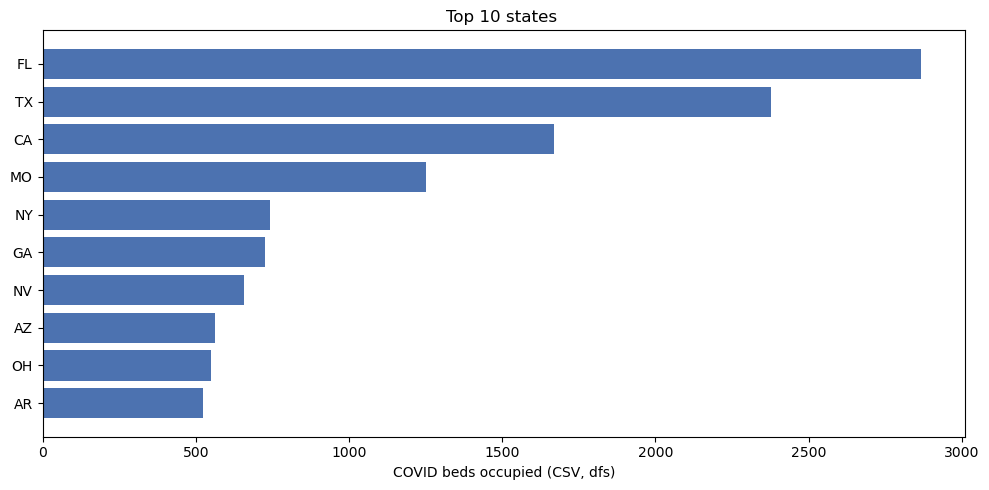

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
top = df4d.head(10).sort_values("covid_beds_used")
ax.barh(top["state"], top["covid_beds_used"], color="#4C72B0")
ax.set_xlabel("COVID beds occupied (CSV, dfs)")
ax.set_title("Top 10 states ")
plt.tight_layout()
plt.show()

### Q4f — `dfs` + `pg` + `mongo`, row-level join

joined row by row on state + date, enriched with `mongo`'s aggregated therapy-center counts per state

In [12]:
q4f = """
WITH hp AS (
    SELECT h.state, h.`date`, CAST(NULLIF(h.inpatient_beds_used_covid, '') AS BIGINT) AS covid_beds_used,
           e.estimated_beds_covid
    FROM dfs.healthdata.`covid/hospital_capacity_clean.csv` h
    JOIN pg.healthdata.estimated_beds e
      ON h.state = e.state
     AND TO_DATE(h.`date`, 'yyyy/MM/dd') = e.collection_date
),
c AS (
    SELECT t.state, COUNT(*) AS num_therapy_centers
    FROM mongo.healthdata.therapeutic t
    WHERE t.provider_status = 'ACTIVE'
    GROUP BY t.state
)
SELECT hp.state, hp.`date`, hp.covid_beds_used, hp.estimated_beds_covid, c.num_therapy_centers
FROM hp
JOIN c ON hp.state = c.state
ORDER BY hp.state, hp.`date`
"""
df4f = drill_query(q4f, label="Q4f dfs+pg+mongo row-level", group="row-level-join")
df4f.head(10)

{'id': {'part1': 1543198665827006569, 'part2': 3049207024457441523}, 'type': 1, 'start': 1788179708060, 'end': 1788179711235, 'query': "\nWITH hp AS (\n    SELECT h.state, h.`date`, CAST(NULLIF(h.inpatient_beds_used_covid, '') AS BIGINT) AS covid_beds_used,\n           e.estimated_beds_covid\n    FROM dfs.healthdata.`covid/hospital_capacity_clean.csv` h\n    JOIN pg.healthdata.estimated_beds e\n      ON h.state = e.state\n     AND TO_DATE(h.`date`, 'yyyy/MM/dd') = e.collection_date\n),\nc AS (\n    SELECT t.state, COUNT(*) AS num_therapy_centers\n    FROM mongo.healthdata.therapeutic t\n    WHERE t.provider_status = 'ACTIVE'\n    GROUP BY t.state\n)\nSELECT hp.state, hp.`date`, hp.covid_beds_used, hp.estimated_beds_covid, c.num_therapy_centers\nFROM hp\nJOIN c ON hp.state = c.state\nORDER BY hp.state, hp.`date`\n", 'plan': '00-00    Screen : rowType = RecordType(ANY state, ANY date, BIGINT covid_beds_used, DECIMAL(0, 0) estimated_beds_covid, BIGINT num_therapy_centers): rowcount = 1.5E

,state,date,covid_beds_used,estimated_beds_covid,num_therapy_centers
0,AK,2021/06/28,15,15.0,49
1,AK,2021/06/29,14,14.0,49
2,AK,2021/06/30,18,17.0,49
3,AK,2021/07/01,19,18.0,49
4,AK,2021/07/02,23,22.0,49
5,AK,2021/07/03,22,21.0,49
6,AK,2021/07/04,24,23.0,49
7,AK,2021/07/05,27,27.0,49
8,AK,2021/07/06,21,21.0,49
9,AK,2021/07/07,30,29.0,49


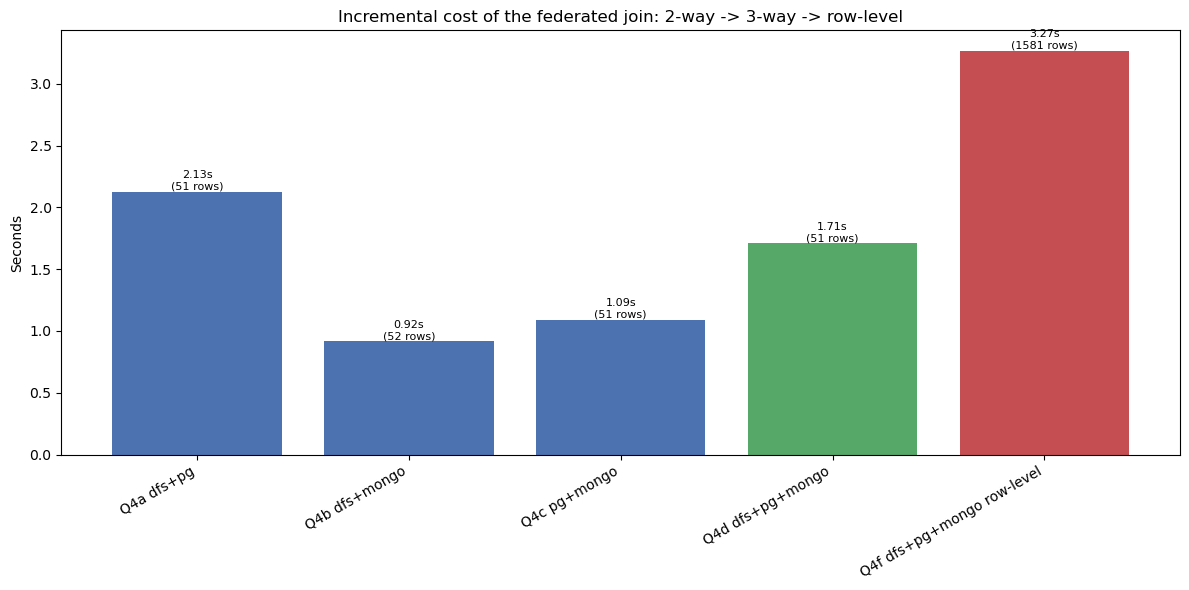

In [13]:
# Incremental cost: execution time as join complexity grows
join_steps = ["Q4a dfs+pg", "Q4b dfs+mongo", "Q4c pg+mongo", "Q4d dfs+pg+mongo",
              "Q4f dfs+pg+mongo row-level"]
df_join_steps = pd.DataFrame(timings)
df_join_steps = df_join_steps[df_join_steps["query"].isin(join_steps)].set_index("query").loc[join_steps]

fig, ax = plt.subplots(figsize=(12, 6))
colors = ["#4C72B0"] * 3 + ["#55A868"] + ["#C44E52"]
ax.bar(df_join_steps.index, df_join_steps["seconds"], color=colors)
ax.set_ylabel("Seconds")
ax.set_title("Incremental cost of the federated join: 2-way -> 3-way -> row-level")
for i, (v, r) in enumerate(zip(df_join_steps["seconds"], df_join_steps["rows"])):
    ax.text(i, v, f"{v:.2f}s\n({r} rows)", ha="center", va="bottom", fontsize=8)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Query 6 — Multi-scale: state + county on the same `dfs` plugin (Dataset 1 + 4)

Two different CSVs same storage plugin

In [14]:
q6 = """
WITH s AS (
    SELECT state, SUM(CAST(NULLIF(inpatient_beds_used_covid, '') AS BIGINT)) AS covid_beds_used
    FROM dfs.healthdata.`covid/hospital_capacity_clean.csv`
    WHERE `date` = '2021/07/09'
    GROUP BY state
)
SELECT s.state,
       s.covid_beds_used   AS state_covid_beds,
       c.county,
       c.cases_last_7_days AS county_cases_7d
FROM s
JOIN dfs.healthdata.`county/community_profile.csv` c
  ON s.state = c.state
ORDER BY state_covid_beds DESC, county_cases_7d DESC
LIMIT 30
"""
df6 = drill_query(q6, label="Q6 dfs-multi-scale", group="other")
df6

{'id': {'part1': 1543198644357339936, 'part2': -6722576056349276147}, 'type': 1, 'start': 1788179713192, 'end': 1788179713793, 'query': "\nWITH s AS (\n    SELECT state, SUM(CAST(NULLIF(inpatient_beds_used_covid, '') AS BIGINT)) AS covid_beds_used\n    FROM dfs.healthdata.`covid/hospital_capacity_clean.csv`\n    WHERE `date` = '2021/07/09'\n    GROUP BY state\n)\nSELECT s.state,\n       s.covid_beds_used   AS state_covid_beds,\n       c.county,\n       c.cases_last_7_days AS county_cases_7d\nFROM s\nJOIN dfs.healthdata.`county/community_profile.csv` c\n  ON s.state = c.state\nORDER BY state_covid_beds DESC, county_cases_7d DESC\nLIMIT 30\n", 'plan': '00-00    Screen : rowType = RecordType(ANY state, BIGINT state_covid_beds, ANY county, ANY county_cases_7d): rowcount = 30.0, cumulative cost = {1020937.515 rows, 5094090.393975985 cpu, 4.0178037E7 io, 0.0 network, 1189472.24 memory}, id = 41979\n00-01      Project(state=[$0], state_covid_beds=[$1], county=[$2], county_cases_7d=[$3]) : row

,state,state_covid_beds,county,county_cases_7d
0,FL,2868,"Volusia County, FL",99
1,FL,2868,"St. Lucie County, FL",90
2,FL,2868,"Wakulla County, FL",9
3,FL,2868,"Osceola County, FL",87
4,FL,2868,"Martin County, FL",85
5,FL,2868,"Collier County, FL",83
6,FL,2868,"Leon County, FL",82
7,FL,2868,"Marion County, FL",82
8,FL,2868,"Putnam County, FL",8
9,FL,2868,"Suwannee County, FL",8


## Summary: execution times by category

In [15]:
df_timings = pd.DataFrame(timings)
df_timings

,query,group,seconds,rows,planning_ms,queued_ms,execution_ms
0,sanity-check,setup,0.150221,1,73,1,30
1,Q1 dfs-csv,single-source,1.205372,20,261,0,616
2,Q2 postgre,single-source,1.058870,20,150,0,822
3,Q3 mongo,single-source,0.247424,20,100,1,38
4,QP point-lookup,single-source,0.112840,1,51,0,5
5,Q4a dfs+pg,2-way-join,2.125679,51,338,1,925
6,Q4b dfs+mongo,2-way-join,0.915422,52,307,0,485
7,Q4c pg+mongo,2-way-join,1.090279,51,203,0,435
8,Q4d dfs+pg+mongo,3-way-join,1.709159,51,502,0,1175
9,Q4f dfs+pg+mongo row-level,row-level-join,3.268813,1581,448,0,2727


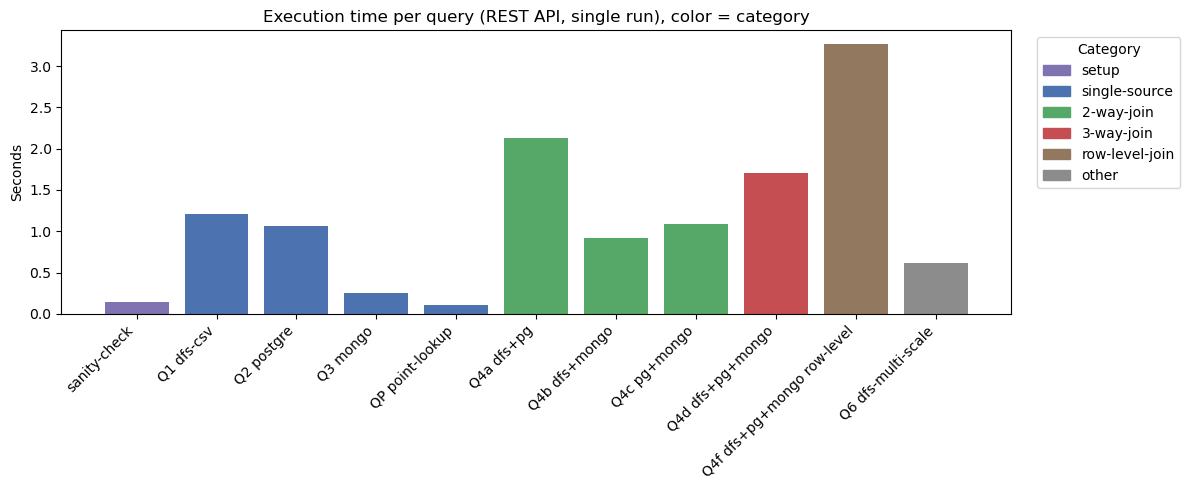

In [16]:
group_colors = {
    "setup": "#8172B2",
    "single-source": "#4C72B0",
    "2-way-join": "#55A868",
    "3-way-join": "#C44E52",
    "row-level-join": "#937860",
    "other": "#8C8C8C",
}
colors = df_timings["group"].map(group_colors)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(df_timings["query"], df_timings["seconds"], color=colors)
ax.set_ylabel("Seconds")
ax.set_title("Execution time per query (REST API, single run), color = category")
plt.xticks(rotation=45, ha="right")

handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in group_colors.values()]
ax.legend(handles, group_colors.keys(), title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Server-Side Breakdown: Planning vs. Queued vs. Execution



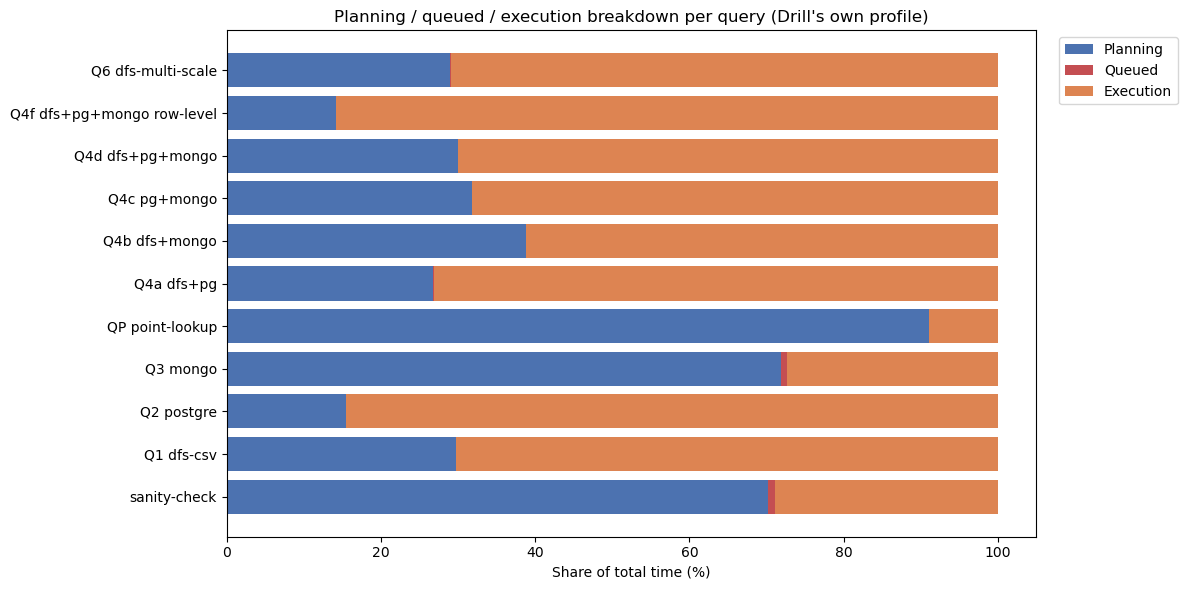

In [17]:
breakdown_cols = ["planning_ms", "queued_ms", "execution_ms"]
df_breakdown = pd.DataFrame(timings).set_index("query")[breakdown_cols]
df_breakdown_pct = df_breakdown.div(df_breakdown.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 6))
bottom = pd.Series(0.0, index=df_breakdown_pct.index)
colors = {"planning_ms": "#4C72B0", "queued_ms": "#C44E52", "execution_ms": "#DD8452"}
labels = {"planning_ms": "Planning", "queued_ms": "Queued", "execution_ms": "Execution"}
for col in breakdown_cols:
    ax.barh(df_breakdown_pct.index, df_breakdown_pct[col], left=bottom, color=colors[col], label=labels[col])
    bottom += df_breakdown_pct[col]
ax.set_xlabel("Share of total time (%)")
ax.set_title("Planning / queued / execution breakdown per query (Drill's own profile)")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

## Conclusions

- Drill queried raw CSV, PostgreSQL, and MongoDB directly, with no ETL, single SQL/REST endpoint.
- Building join shows cost grows both with the number of sources (2-way → 3-way) and, more sharply, when moving from a pre-aggregated join to a row-level join on a composite key: less work happens near the data, more falls on Drill in memory.
- Schema-on-read lets you query "dirty" data  Query 1  inline, via `every other quer y reads the same column already cleaned upstream, keeps the join queries themselves short.